# 0–9 数字的对角线编码可视化

编码函数：`encode_diagonal(k, n=10)`

- 对每个数字 $k\in\{0,\dots,9\}$，生成一个 $10\times10$ 的0/1矩阵；
- 每一行恰好有一个1，位置满足：$j=(i+k)\bmod 10$；
- 因此不同数字对应“同一条斜线的循环平移”。

下面给出两种图：
1. 每个数字各自的编码矩阵（2×5）；
2. 1的位置坐标图（更直观看出“平移”规律）。

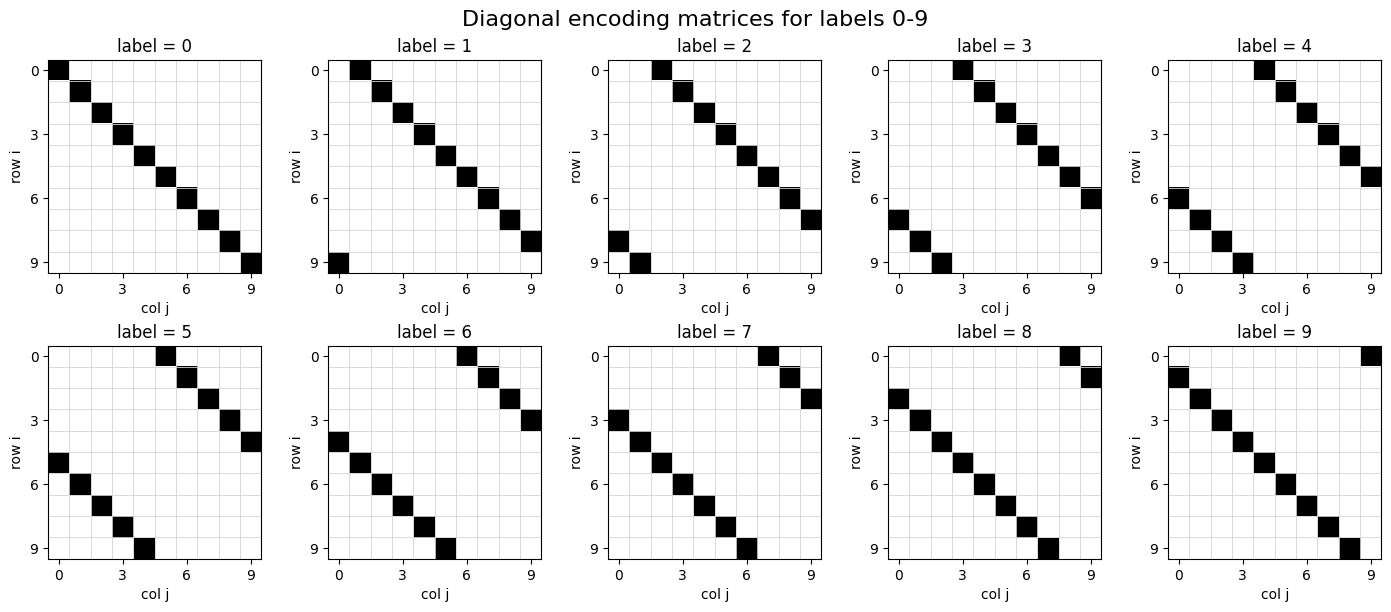

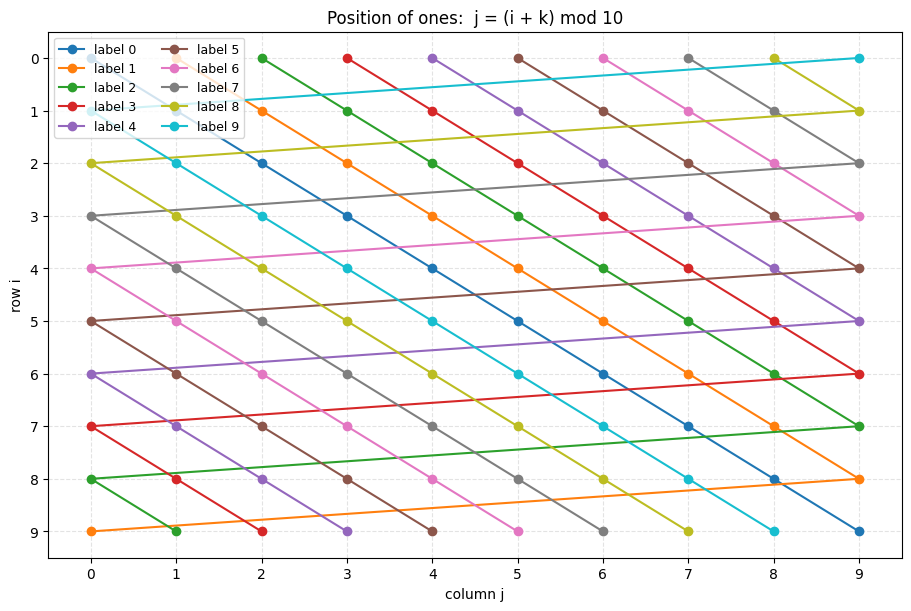

每个数字k对应一个10x10二值矩阵，每行仅有一个1，位置满足 j=(i+k)%10。
k不同 -> 整条斜线发生循环平移。


In [3]:
from Encode_0to9 import encode_diagonal
import numpy as np
import matplotlib.pyplot as plt

# 参数
n = 10
labels = list(range(10))
encoded = np.array([encode_diagonal(k, n=n) for k in labels])  # (10, 10, 10)

# -------- 图1：2x5 展示每个数字的编码矩阵 --------
fig, axes = plt.subplots(2, 5, figsize=(14, 6), constrained_layout=True)
for idx, k in enumerate(labels):
    ax = axes[idx // 5, idx % 5]
    mat = encoded[idx]

    # 用高对比度 colormap，0白1深色
    im = ax.imshow(mat, cmap="binary", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"label = {k}", fontsize=12)

    # 网格线帮助看清每个格子
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 只保留关键刻度，避免拥挤
    ax.set_xticks([0, 3, 6, 9])
    ax.set_yticks([0, 3, 6, 9])
    ax.set_xlabel("col j")
    ax.set_ylabel("row i")

fig.suptitle("Diagonal encoding matrices for labels 0-9", fontsize=16)
plt.show()

# -------- 图2：显示“1”的坐标，突出平移规律 j=(i+k)%n --------
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for k, c in zip(labels, colors):
    rows = np.arange(n)
    cols = (rows + k) % n
    ax.plot(cols, rows, 'o-', color=c, label=f"label {k}")

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)  # 反转y轴，和矩阵显示方向一致
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlabel("column j")
ax.set_ylabel("row i")
ax.set_title("Position of ones:  j = (i + k) mod 10")
ax.legend(ncol=2, fontsize=9)
plt.show()

# 简短打印说明
print("每个数字k对应一个10x10二值矩阵，每行仅有一个1，位置满足 j=(i+k)%10。")
print("k不同 -> 整条斜线发生循环平移。")